In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (913000, 4)
Test shape: (45000, 4)


In [4]:
print(train.columns)
print(test.columns)

Index(['date', 'store', 'item', 'sales'], dtype='object')
Index(['id', 'date', 'store', 'item'], dtype='object')


In [5]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [6]:
print(train.dtypes)
print()
print(train.head())
print()
print("Date range:")
print(train["date"].min(), "to", train["date"].max())

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10

Date range:
2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [7]:
print(train.dtypes)

print()

print(train.head())

print()

print("Date range:")
print(train["date"].min(), "to", train["date"].max())

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10

Date range:
2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [8]:
print("Missing values:")
print(train.isnull().sum())

print("\nDuplicate rows:")
print(train.duplicated().sum())

print("\nUnique stores:")
print(train["store"].nunique())

print("\nUnique items:")
print(train["item"].nunique())

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate rows:
0

Unique stores:
10

Unique items:
50


In [9]:
print(train["sales"].describe())

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


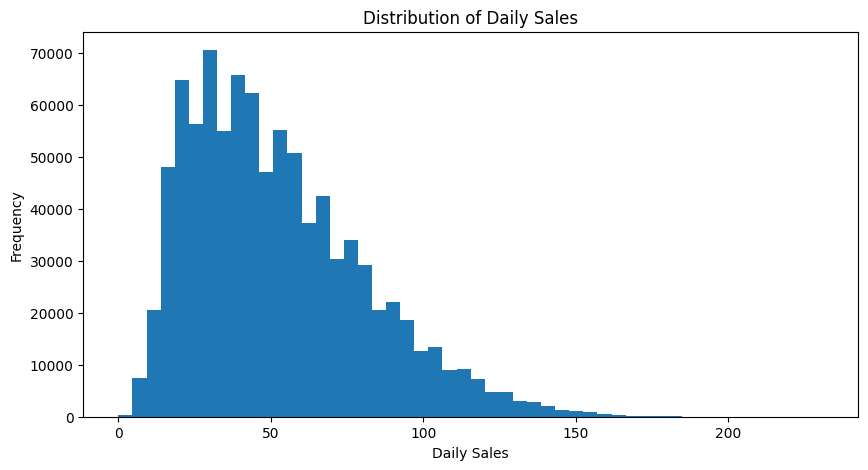

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(train["sales"], bins=50)

plt.xlabel("Daily Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Sales")

plt.show()

In [11]:
store_sales = train.groupby("store")["sales"].sum().sort_values(ascending=False)

print(store_sales)

store
2     6120128
8     5856169
3     5435144
10    5360158
9     5025976
4     5012639
1     4315603
5     3631016
6     3627670
7     3320009
Name: sales, dtype: int64


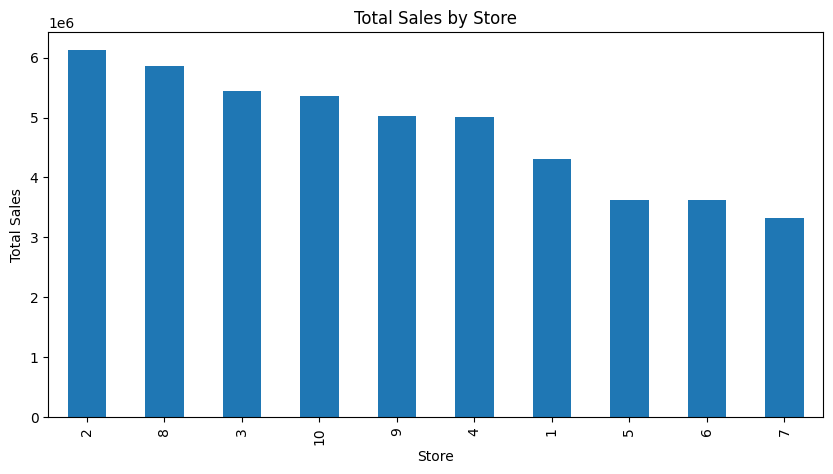

In [12]:
plt.figure(figsize=(10, 5))

store_sales.plot(kind="bar")

plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.title("Total Sales by Store")

plt.show()

In [13]:
item_sales = train.groupby("item")["sales"].sum().sort_values(ascending=False)

print(item_sales)

item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
45    1471467
38    1470330
22    1469971
36    1406548
8     1405108
10    1337133
11    1271925
12    1271534
29    1271240
33    1270183
24    1205975
50    1203009
35    1201541
14    1071531
31    1070845
46    1070764
2     1069564
7     1068777
6     1068281
9      938379
48     937703
43     936635
26     869981
20     867641
32     803107
39     801311
19     736892
30     736554
21     736190
42     669925
3      669087
17     602486
44     536811
49     535663
23     534979
37     534258
40     534094
34     469935
16     468480
27     402628
4      401907
47     401781
41     401759
1      401384
5      335230
Name: sales, dtype: int64


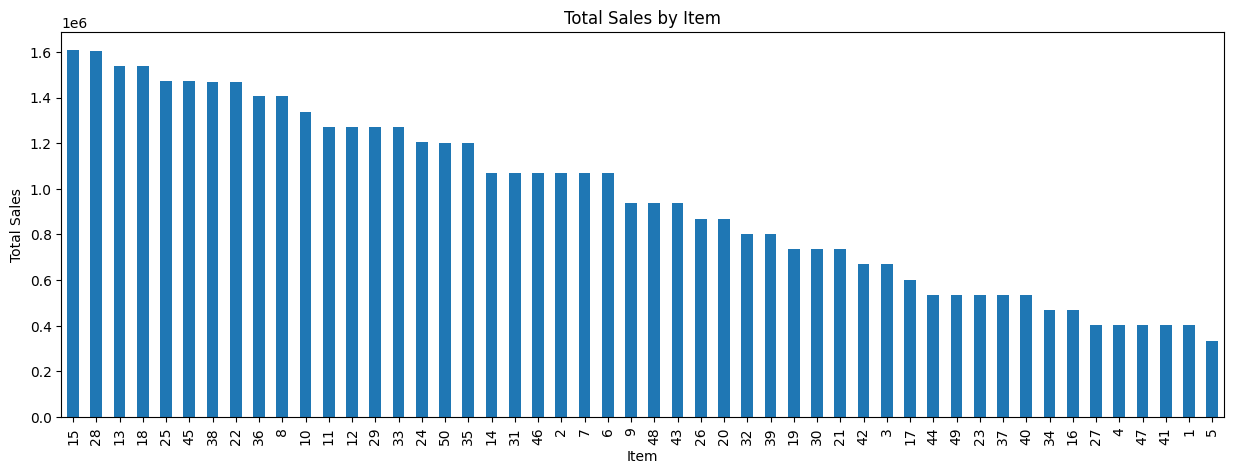

In [14]:
plt.figure(figsize=(15, 5))

item_sales.plot(kind="bar")

plt.xlabel("Item")
plt.ylabel("Total Sales")
plt.title("Total Sales by Item")

plt.show()

In [15]:
daily_sales = train.groupby("date")["sales"].sum()

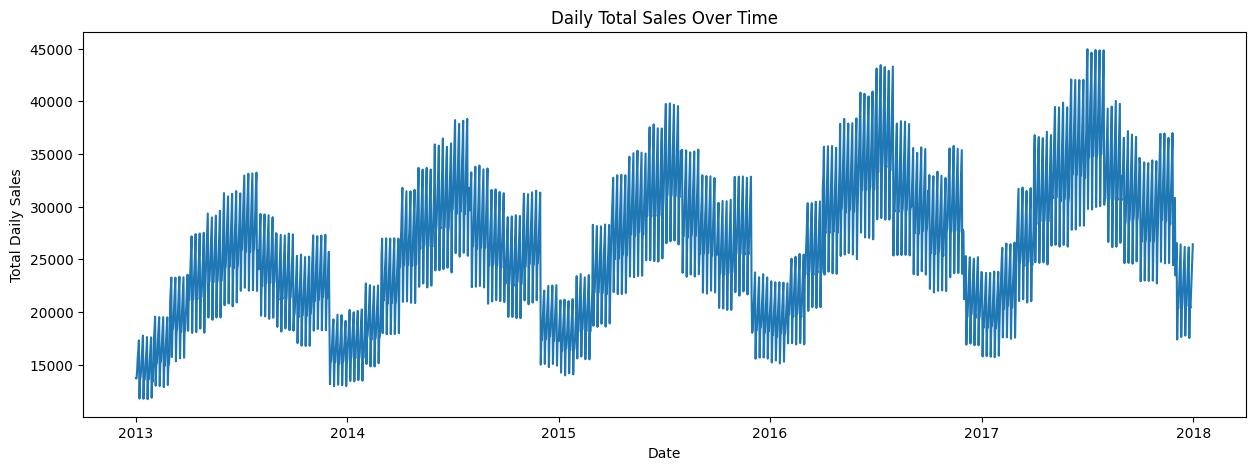

In [16]:
plt.figure(figsize=(15, 5))

plt.plot(daily_sales)

plt.xlabel("Date")
plt.ylabel("Total Daily Sales")
plt.title("Daily Total Sales Over Time")

plt.show()

In [17]:
train["day_of_week"] = train["date"].dt.dayofweek

In [18]:
weekly_sales = train.groupby("day_of_week")["sales"].mean()

print(weekly_sales)

day_of_week
0    41.429638
1    48.225908
2    48.368506
3    51.723218
4    55.157249
5    58.662697
6    62.143333
Name: sales, dtype: float64


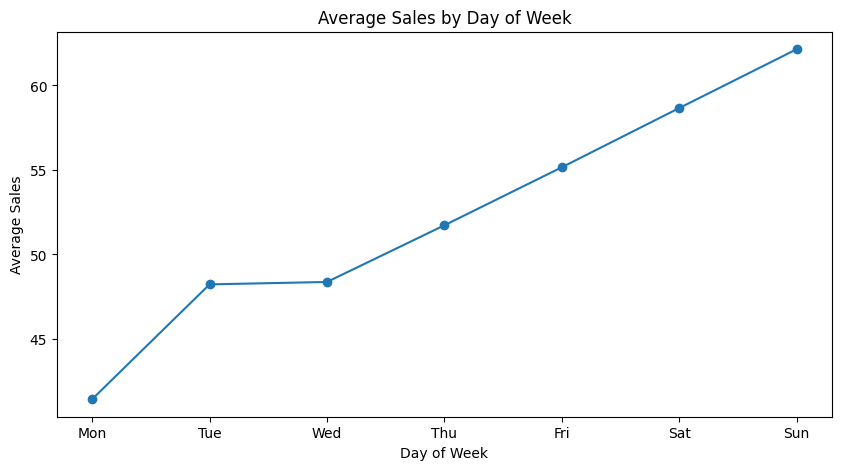

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(weekly_sales.index, weekly_sales.values, marker="o")

plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")

plt.show()

In [20]:
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month

In [21]:
print(train[["date", "year", "month"]].head())

        date  year  month
0 2013-01-01  2013      1
1 2013-01-02  2013      1
2 2013-01-03  2013      1
3 2013-01-04  2013      1
4 2013-01-05  2013      1


In [22]:
monthly_sales = train.groupby("month")["sales"].mean()

print(monthly_sales)

month
1     35.524503
2     39.378397
3     47.305574
4     55.152893
5     59.128219
6     63.025480
7     66.998619
8     59.105226
9     55.072760
10    51.193806
11    55.218080
12    39.365265
Name: sales, dtype: float64


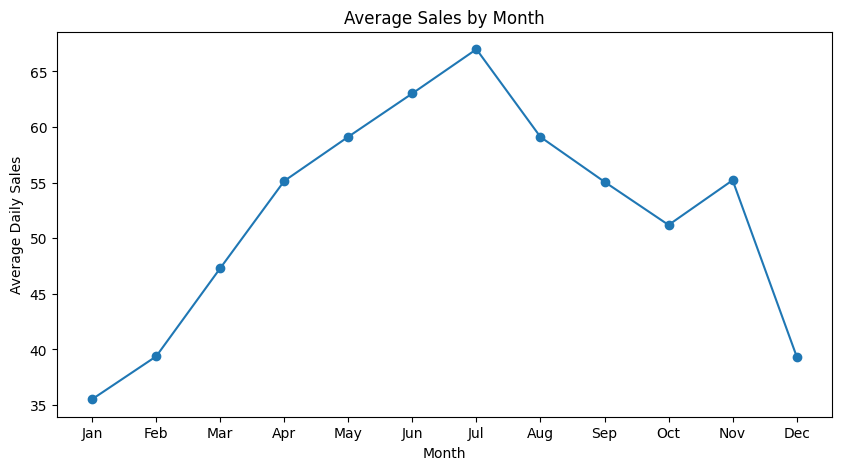

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.title("Average Sales by Month")

plt.show()

In [24]:
yearly_sales = train.groupby("year")["sales"].sum()

print(yearly_sales)

year
2013     7941243
2014     9135482
2015     9536887
2016    10357160
2017    10733740
Name: sales, dtype: int64


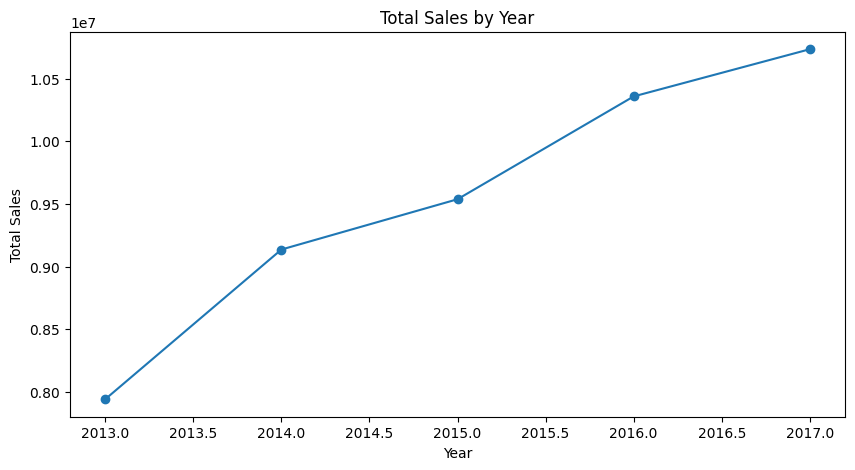

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Year")

plt.show()

In [26]:
yearly_avg = train.groupby("year")["sales"].mean()

print(yearly_avg)

year
2013    43.513660
2014    50.057436
2015    52.256915
2016    56.596503
2017    58.815014
Name: sales, dtype: float64


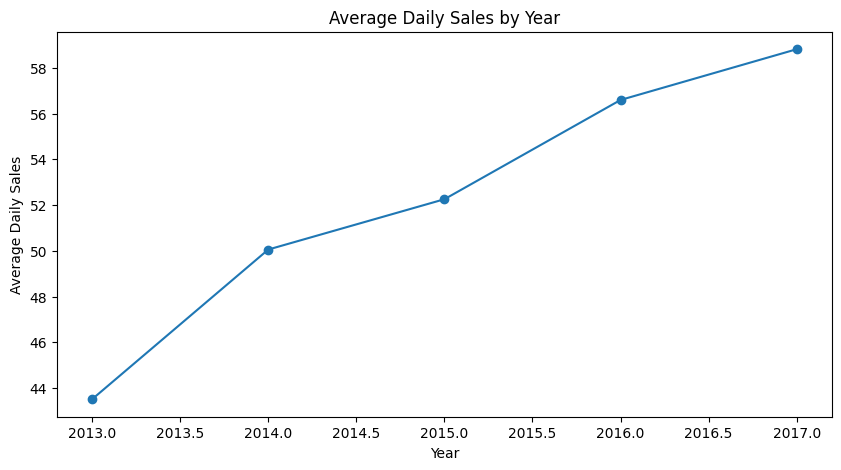

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Daily Sales")
plt.title("Average Daily Sales by Year")

plt.show()

In [28]:
month_year = train.pivot_table(
    values="sales",
    index="month",
    columns="year",
    aggfunc="mean"
)

print(month_year)

year        2013       2014       2015       2016       2017
month                                                       
1      29.348645  33.934645  35.646000  38.867032  39.826194
2      32.815500  37.794071  39.379786  42.410828  44.383500
3      39.831097  45.438774  47.158129  51.024581  53.075290
4      45.484933  52.594267  54.964467  60.130000  62.590800
5      49.241419  56.959806  59.800129  63.789032  65.850710
6      53.039800  60.456133  62.478933  68.177600  70.974933
7      55.220774  63.807097  66.925806  73.465677  75.573742
8      49.468452  57.135226  59.380710  63.322194  66.219548
9      45.993800  52.341600  54.888800  59.788733  62.350867
10     42.360452  48.960194  51.435677  55.718516  57.494194
11     46.176200  53.385533  55.176333  59.429867  61.922467
12     32.684323  37.293419  39.198194  42.800710  44.849677


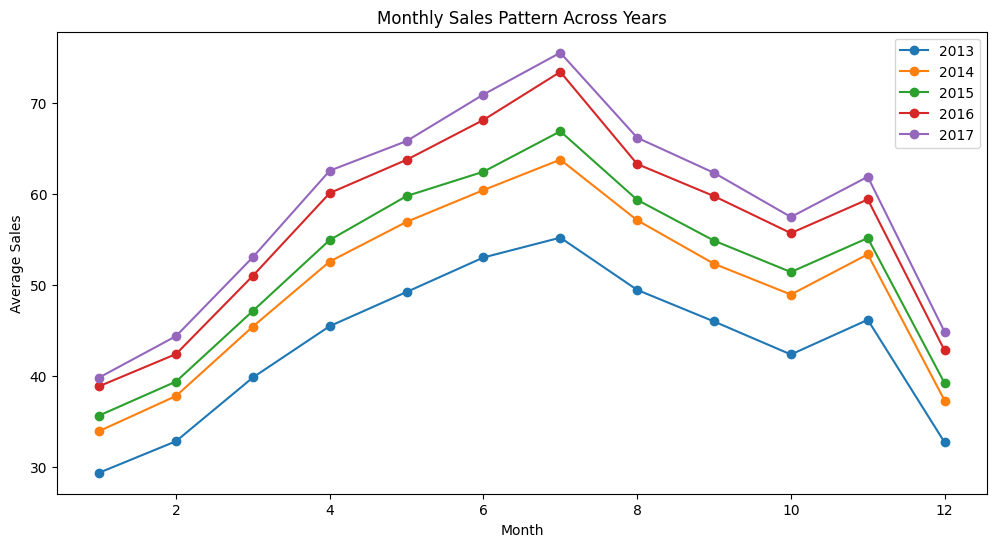

In [29]:
plt.figure(figsize=(12, 6))

for year in month_year.columns:
    plt.plot(
        month_year.index,
        month_year[year],
        marker="o",
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Monthly Sales Pattern Across Years")
plt.legend()

plt.show()

In [30]:
store_item_sales = (
    train
    .groupby(["store", "item"])["sales"]
    .mean()
    .sort_values(ascending=False)
)

print(store_item_sales.head(20))

store  item
2      28      112.638007
       15      112.578861
       18      108.117196
8      15      108.047645
2      13      107.903067
8      28      107.813253
       18      103.820372
       13      103.819825
2      25      103.426068
       45      103.381161
       38      103.249179
       22      103.009858
3      15      100.423330
       28      100.143483
8      25       99.244797
2      8        99.090361
10     15       98.990690
8      38       98.947974
       45       98.941402
       22       98.914567
Name: sales, dtype: float64


In [31]:
print(store_item_sales.tail(20))

store  item
7      16      17.754107
5      41      16.830778
6      27      16.809419
5      4       16.776561
       27      16.763417
6      4       16.754107
5      1       16.739321
6      1       16.717963
       47      16.708653
5      47      16.699343
1      5       16.612815
6      41      16.607338
7      47      15.479189
       41      15.471522
       4       15.358160
       27      15.213582
       1       15.159365
5      5       14.086528
6      5       13.893209
7      5       12.733844
Name: sales, dtype: float64


In [32]:
train = train.sort_values(
    ["store", "item", "date"]
).reset_index(drop=True)

In [33]:
train["lag_1"] = train.groupby(
    ["store", "item"]
)["sales"].shift(1)

train["lag_7"] = train.groupby(
    ["store", "item"]
)["sales"].shift(7)

train["lag_14"] = train.groupby(
    ["store", "item"]
)["sales"].shift(14)

train["lag_28"] = train.groupby(
    ["store", "item"]
)["sales"].shift(28)

train["lag_365"] = train.groupby(
    ["store", "item"]
)["sales"].shift(365)

In [34]:
print(
    train[
        [
            "date",
            "store",
            "item",
            "sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "lag_365"
        ]
    ].head(20)
)

         date  store  item  sales  lag_1  lag_7  lag_14  lag_28  lag_365
0  2013-01-01      1     1     13    NaN    NaN     NaN     NaN      NaN
1  2013-01-02      1     1     11   13.0    NaN     NaN     NaN      NaN
2  2013-01-03      1     1     14   11.0    NaN     NaN     NaN      NaN
3  2013-01-04      1     1     13   14.0    NaN     NaN     NaN      NaN
4  2013-01-05      1     1     10   13.0    NaN     NaN     NaN      NaN
5  2013-01-06      1     1     12   10.0    NaN     NaN     NaN      NaN
6  2013-01-07      1     1     10   12.0    NaN     NaN     NaN      NaN
7  2013-01-08      1     1      9   10.0   13.0     NaN     NaN      NaN
8  2013-01-09      1     1     12    9.0   11.0     NaN     NaN      NaN
9  2013-01-10      1     1      9   12.0   14.0     NaN     NaN      NaN
10 2013-01-11      1     1      9    9.0   13.0     NaN     NaN      NaN
11 2013-01-12      1     1      7    9.0   10.0     NaN     NaN      NaN
12 2013-01-13      1     1     10    7.0   12.0    

In [35]:
grp = train.groupby(["store", "item"])["sales"]

train["rolling_7"] = grp.transform(
    lambda x: x.shift(1).rolling(7).mean()
)

train["rolling_14"] = grp.transform(
    lambda x: x.shift(1).rolling(14).mean()
)

train["rolling_28"] = grp.transform(
    lambda x: x.shift(1).rolling(28).mean()
)

In [36]:
print(
    train[
        [
            "date",
            "store",
            "item",
            "sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "lag_365",
            "rolling_7",
            "rolling_14",
            "rolling_28"
        ]
    ].tail(20)
)

             date  store  item  sales  lag_1  lag_7  lag_14  lag_28  lag_365  \
912980 2017-12-12     10    50     67   54.0   68.0    68.0    72.0     51.0   
912981 2017-12-13     10    50     67   67.0   60.0    76.0    88.0     69.0   
912982 2017-12-14     10    50     72   67.0   66.0    73.0    84.0     53.0   
912983 2017-12-15     10    50     72   72.0   67.0    66.0    95.0     63.0   
912984 2017-12-16     10    50     52   72.0   69.0    49.0    99.0     69.0   
912985 2017-12-17     10    50     86   52.0   69.0    75.0    88.0     67.0   
912986 2017-12-18     10    50     53   86.0   54.0    54.0    62.0     65.0   
912987 2017-12-19     10    50     54   53.0   67.0    68.0    81.0     44.0   
912988 2017-12-20     10    50     51   54.0   67.0    60.0    81.0     58.0   
912989 2017-12-21     10    50     63   51.0   72.0    66.0    87.0     64.0   
912990 2017-12-22     10    50     75   63.0   72.0    67.0    81.0     56.0   
912991 2017-12-23     10    50     70   

In [37]:
print(train[
    [
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_28",
        "lag_365",
        "rolling_7",
        "rolling_14",
        "rolling_28"
    ]
].isnull().sum())

lag_1            500
lag_7           3500
lag_14          7000
lag_28         14000
lag_365       182500
rolling_7       3500
rolling_14      7000
rolling_28     14000
dtype: int64


In [38]:
print(train["date"].min())
print(train["date"].max())

2013-01-01 00:00:00
2017-12-31 00:00:00


In [39]:
train_data = train[
    train["date"] < "2017-10-01"
].copy()

val_data = train[
    train["date"] >= "2017-10-01"
].copy()

In [40]:
print("Training data:", train_data.shape)
print("Validation data:", val_data.shape)

print("\nTraining dates:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nValidation dates:")
print(val_data["date"].min(), "to", val_data["date"].max())

Training data: (867000, 15)
Validation data: (46000, 15)

Training dates:
2013-01-01 00:00:00 to 2017-09-30 00:00:00

Validation dates:
2017-10-01 00:00:00 to 2017-12-31 00:00:00


In [41]:
print(len(train_data))
print(len(val_data))

867000
46000


In [42]:
features = [
    "store",
    "item",
    "year",
    "month",
    "day_of_week",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_365",
    "rolling_7",
    "rolling_14",
    "rolling_28"
]

target = "sales"

In [43]:
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

In [44]:
print(X_train.isnull().sum())

store               0
item                0
year                0
month               0
day_of_week         0
lag_1             500
lag_7            3500
lag_14           7000
lag_28          14000
lag_365        182500
rolling_7        3500
rolling_14       7000
rolling_28      14000
dtype: int64


In [45]:
train_data = train_data.dropna(subset=features)
val_data = val_data.dropna(subset=features)

In [46]:
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

In [47]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())

0
0


In [48]:
baseline_pred = val_data["lag_7"]

In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        val_data["sales"],
        baseline_pred
    )
)

print("Baseline RMSE:", rmse)

Baseline RMSE: 12.050653058255175


In [50]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    val_data["sales"],
    baseline_pred
)

print("Baseline MAE:", mae)

Baseline MAE: 9.076326086956522


In [51]:
comparison = val_data[
    ["date", "store", "item", "sales", "lag_7"]
].head(20)

print(comparison)

           date  store  item  sales  lag_7
1734 2017-10-01      1     1     21   24.0
1735 2017-10-02      1     1     12   14.0
1736 2017-10-03      1     1     18   18.0
1737 2017-10-04      1     1     15   27.0
1738 2017-10-05      1     1     20   23.0
1739 2017-10-06      1     1     19   28.0
1740 2017-10-07      1     1     22   30.0
1741 2017-10-08      1     1     19   21.0
1742 2017-10-09      1     1      9   12.0
1743 2017-10-10      1     1     23   18.0
1744 2017-10-11      1     1     14   15.0
1745 2017-10-12      1     1     24   20.0
1746 2017-10-13      1     1     23   19.0
1747 2017-10-14      1     1     26   22.0
1748 2017-10-15      1     1     28   19.0
1749 2017-10-16      1     1     19    9.0
1750 2017-10-17      1     1     17   23.0
1751 2017-10-18      1     1     15   14.0
1752 2017-10-19      1     1     26   24.0
1753 2017-10-20      1     1     22   23.0


In [52]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 684500, number of used features: 13
[LightGBM] [Info] Start training from score 54.416511


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, random_state=42, subsample=0.8)

In [53]:
ml_pred = model.predict(X_val)

In [54]:
ml_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ml_pred
    )
)

print("ML Model RMSE:", ml_rmse)

ML Model RMSE: 7.8778078170427275


In [55]:
ml_mae = mean_absolute_error(
    y_val,
    ml_pred
)

print("ML Model MAE:", ml_mae)

ML Model MAE: 6.087253930256939


In [56]:
print("Baseline RMSE:", rmse)
print("ML RMSE:", ml_rmse)

print()

print("Baseline MAE:", mae)
print("ML MAE:", ml_mae)

Baseline RMSE: 12.050653058255175
ML RMSE: 7.8778078170427275

Baseline MAE: 9.076326086956522
ML MAE: 6.087253930256939


In [57]:
train["day_of_year"] = train["date"].dt.dayofyear

In [58]:
train["week_of_year"] = train["date"].dt.isocalendar().week.astype(int)

In [59]:
train["is_weekend"] = (
    train["day_of_week"] >= 5
).astype(int)

In [60]:
grp = train.groupby(["store", "item"])["sales"]

train["rolling_median_7"] = grp.transform(
    lambda x: x.shift(1).rolling(7).median()
)

train["rolling_median_28"] = grp.transform(
    lambda x: x.shift(1).rolling(28).median()
)

In [61]:
train["rolling_std_7"] = grp.transform(
    lambda x: x.shift(1).rolling(7).std()
)

train["rolling_std_28"] = grp.transform(
    lambda x: x.shift(1).rolling(28).std()
)

In [62]:
train["rolling_60"] = grp.transform(
    lambda x: x.shift(1).rolling(60).mean()
)

train["rolling_90"] = grp.transform(
    lambda x: x.shift(1).rolling(90).mean()
)

In [63]:
features = [
    "store",
    "item",

    "year",
    "month",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "is_weekend",

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_365",

    "rolling_7",
    "rolling_14",
    "rolling_28",
    "rolling_60",
    "rolling_90",

    "rolling_median_7",
    "rolling_median_28",

    "rolling_std_7",
    "rolling_std_28"
]

In [64]:
train_data = train[
    train["date"] < "2017-10-01"
].copy()

val_data = train[
    train["date"] >= "2017-10-01"
].copy()

In [65]:
train_data = train_data.dropna(subset=features)
val_data = val_data.dropna(subset=features)

In [66]:
X_train = train_data[features]
y_train = train_data["sales"]

X_val = val_data[features]
y_val = val_data["sales"]

In [67]:
print(X_train.shape)
print(X_val.shape)

print("Missing values:", X_train.isnull().sum().sum())

(684500, 22)
(46000, 22)
Missing values: 0


In [68]:
from lightgbm import LGBMRegressor

model2 = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model2.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3558
[LightGBM] [Info] Number of data points in the train set: 684500, number of used features: 22
[LightGBM] [Info] Start training from score 54.416511


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1500,
              n_jobs=-1, num_leaves=63, random_state=42, subsample=0.8)

In [69]:
pred2 = model2.predict(X_val)

rmse2 = np.sqrt(
    mean_squared_error(y_val, pred2)
)

mae2 = mean_absolute_error(
    y_val,
    pred2
)

print("Improved RMSE:", rmse2)
print("Improved MAE:", mae2)

Improved RMSE: 7.618009575617826
Improved MAE: 5.886764262174511


In [70]:
print("Baseline RMSE :", rmse)
print("Old ML RMSE   :", ml_rmse)
print("New ML RMSE   :", rmse2)

print()

print("Baseline MAE  :", mae)
print("Old ML MAE    :", ml_mae)
print("New ML MAE    :", mae2)

Baseline RMSE : 12.050653058255175
Old ML RMSE   : 7.8778078170427275
New ML RMSE   : 7.618009575617826

Baseline MAE  : 9.076326086956522
Old ML MAE    : 6.087253930256939
New ML MAE    : 5.886764262174511


In [71]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model2.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

              feature  importance
5         day_of_year        8480
17         rolling_90        7971
13          rolling_7        6615
9               lag_7        6121
12            lag_365        5804
10             lag_14        5674
8               lag_1        5515
11             lag_28        5350
16         rolling_60        4896
20      rolling_std_7        4157
3               month        4045
14         rolling_14        3946
4         day_of_week        3911
21     rolling_std_28        3539
19  rolling_median_28        3259
18   rolling_median_7        3172
6        week_of_year        2996
15         rolling_28        2731
1                item        2244
0               store        1192
2                year        1062
7          is_weekend         320


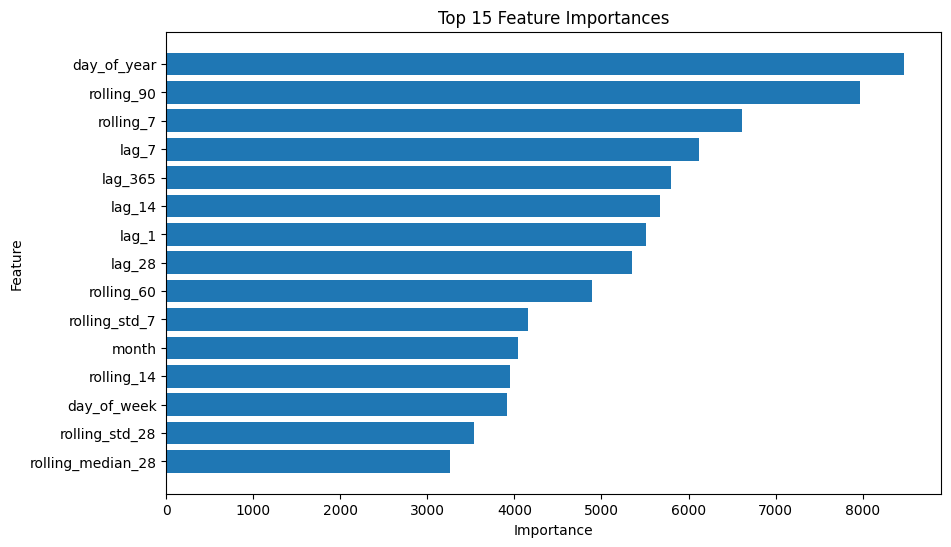

In [72]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [73]:
final_train = train.dropna(subset=features).copy()

X_final = final_train[features]
y_final = final_train["sales"]

print("Final training shape:", X_final.shape)

Final training shape: (730500, 22)


In [74]:
final_model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_final,
    y_final
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.201030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3541
[LightGBM] [Info] Number of data points in the train set: 730500, number of used features: 22
[LightGBM] [Info] Start training from score 54.432949


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1500,
              n_jobs=-1, num_leaves=63, random_state=42, subsample=0.8)

In [75]:
future = test.copy()

future["year"] = future["date"].dt.year
future["month"] = future["date"].dt.month
future["day_of_week"] = future["date"].dt.dayofweek
future["day_of_year"] = future["date"].dt.dayofyear
future["week_of_year"] = (
    future["date"].dt.isocalendar().week.astype(int)
)
future["is_weekend"] = (
    future["day_of_week"] >= 5
).astype(int)

In [76]:
print(future.head())

   id       date  store  item  year  month  day_of_week  day_of_year  \
0   0 2018-01-01      1     1  2018      1            0            1   
1   1 2018-01-02      1     1  2018      1            1            2   
2   2 2018-01-03      1     1  2018      1            2            3   
3   3 2018-01-04      1     1  2018      1            3            4   
4   4 2018-01-05      1     1  2018      1            4            5   

   week_of_year  is_weekend  
0             1           0  
1             1           0  
2             1           0  
3             1           0  
4             1           0  


In [77]:
history = (
    train[
        ["date", "store", "item", "sales"]
    ]
    .copy()
)

history_dict = {}

for row in history.itertuples(index=False):
    key = (row.store, row.item)

    if key not in history_dict:
        history_dict[key] = []

    history_dict[key].append(
        (row.date, row.sales)
    )

In [78]:
for key in history_dict:
    history_dict[key].sort(
        key=lambda x: x[0]
    )

In [79]:
predictions = []

future_dates = sorted(
    future["date"].unique()
)

In [80]:
for current_date in future_dates:

    day_data = future[
        future["date"] == current_date
    ].copy()

    for idx, row in day_data.iterrows():

        key = (row["store"], row["item"])

        hist = history_dict[key]

        sales_values = [
            x[1] for x in hist
        ]

        # Lag features
        lag_1 = sales_values[-1]
        lag_7 = sales_values[-7]
        lag_14 = sales_values[-14]
        lag_28 = sales_values[-28]
        lag_365 = sales_values[-365]

        # Rolling features
        rolling_7 = np.mean(
            sales_values[-7:]
        )

        rolling_14 = np.mean(
            sales_values[-14:]
        )

        rolling_28 = np.mean(
            sales_values[-28:]
        )

        rolling_60 = np.mean(
            sales_values[-60:]
        )

        rolling_90 = np.mean(
            sales_values[-90:]
        )

        rolling_median_7 = np.median(
            sales_values[-7:]
        )

        rolling_median_28 = np.median(
            sales_values[-28:]
        )

        rolling_std_7 = np.std(
            sales_values[-7:]
        )

        rolling_std_28 = np.std(
            sales_values[-28:]
        )

        # Create model input
        row_data = pd.DataFrame([{
            "store": row["store"],
            "item": row["item"],
            "year": row["year"],
            "month": row["month"],
            "day_of_week": row["day_of_week"],
            "day_of_year": row["day_of_year"],
            "week_of_year": row["week_of_year"],
            "is_weekend": row["is_weekend"],

            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "lag_28": lag_28,
            "lag_365": lag_365,

            "rolling_7": rolling_7,
            "rolling_14": rolling_14,
            "rolling_28": rolling_28,
            "rolling_60": rolling_60,
            "rolling_90": rolling_90,

            "rolling_median_7": rolling_median_7,
            "rolling_median_28": rolling_median_28,

            "rolling_std_7": rolling_std_7,
            "rolling_std_28": rolling_std_28
        }])

        prediction = final_model.predict(
            row_data[features]
        )[0]

        # Demand cannot be negative
        prediction = max(0, prediction)

        predictions.append({
            "id": row["id"],
            "date": current_date,
            "store": row["store"],
            "item": row["item"],
            "sales": prediction
        })

        # Add prediction to history
        history_dict[key].append(
            (current_date, prediction)
        )

In [81]:
pred_df = pd.DataFrame(predictions)

print(pred_df.head())
print(pred_df.shape)

    id       date  store  item      sales
0    0 2018-01-01      1     1  12.241909
1   90 2018-01-01      2     1  16.677069
2  180 2018-01-01      3     1  16.311946
3  270 2018-01-01      4     1  15.094534
4  360 2018-01-01      5     1  11.471678
(45000, 5)


In [82]:
submission = pred_df[
    ["id", "sales"]
].copy()

In [83]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [84]:
print(submission.head())
print(submission.shape)

    id      sales
0    0  12.241909
1   90  16.677069
2  180  16.311946
3  270  15.094534
4  360  11.471678
(45000, 2)


In [85]:
print(submission.isnull().sum())
print(submission["sales"].describe())

id       0
sales    0
dtype: int64
count    45000.000000
mean        48.184159
std         24.118500
min          8.759376
25%         28.375230
50%         44.607483
75%         63.715277
max        143.162354
Name: sales, dtype: float64


In [86]:
print("Minimum prediction:", submission["sales"].min())
print("Maximum prediction:", submission["sales"].max())
print("Average prediction:", submission["sales"].mean())

Minimum prediction: 8.7593759825421
Maximum prediction: 143.16235439359883
Average prediction: 48.18415914650614


In [87]:
assert len(submission) == len(test)

In [90]:
print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())
print("Missing values:")
print(submission.isnull().sum())

print("\nDuplicate IDs:", submission["id"].duplicated().sum())

print("\nNegative predictions:", (submission["sales"] < 0).sum())

Rows: 45000
Columns: ['id', 'sales']
Missing values:
id       0
sales    0
dtype: int64

Duplicate IDs: 0

Negative predictions: 0


In [92]:
submission = test[["id"]].copy()

submission = submission.merge(
    pred_df[["id", "sales"]],
    on="id",
    how="left",
    sort=False
)

In [95]:
submission = test[["id"]].copy()
pred_lookup = pred_df[["id", "sales"]].drop_duplicates("id")


submission = submission.merge(
    pred_lookup,
    on="id",
    how="left",
    sort=False
)

submission = submission[["id", "sales"]]
submission = submission.reset_index(drop=True)

In [96]:
print(submission.head(10))
print(test[["id"]].head(10))

print("\nIDs match:")
print(submission["id"].tolist() == test["id"].tolist())

   id      sales
0   0  12.241909
1   1  14.389543
2   2  14.497736
3   3  15.367165
4   4  16.327567
5   5  18.006611
6   6  18.935508
7   7  12.905056
8   8  15.051240
9   9  14.457337
   id
0   0
1   1
2   2
3   3
4   4
5   5
6   6
7   7
8   8
9   9

IDs match:
True


In [97]:
assert len(submission) == len(test)
assert submission["id"].tolist() == test["id"].tolist()
assert submission["sales"].isna().sum() == 0
assert (submission["sales"] >= 0).all()
assert submission["id"].duplicated().sum() == 0

print("✅ ALL CHECKS PASSED")

✅ ALL CHECKS PASSED


In [98]:
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created")
print(submission.shape)

✅ submission.csv created
(45000, 2)


In [99]:
print(submission.head(10))
print(submission.tail(10))

print("\nShape:", submission.shape)

print("\nStatistics:")
print(submission["sales"].describe())

   id      sales
0   0  12.241909
1   1  14.389543
2   2  14.497736
3   3  15.367165
4   4  16.327567
5   5  18.006611
6   6  18.935508
7   7  12.905056
8   8  15.051240
9   9  14.457337
          id      sales
44990  44990  78.028156
44991  44991  83.219492
44992  44992  87.393807
44993  44993  93.512094
44994  44994  62.324299
44995  44995  73.160663
44996  44996  73.394016
44997  44997  78.823212
44998  44998  84.193773
44999  44999  90.221674

Shape: (45000, 2)

Statistics:
count    45000.000000
mean        48.184159
std         24.118500
min          8.759376
25%         28.375230
50%         44.607483
75%         63.715277
max        143.162354
Name: sales, dtype: float64


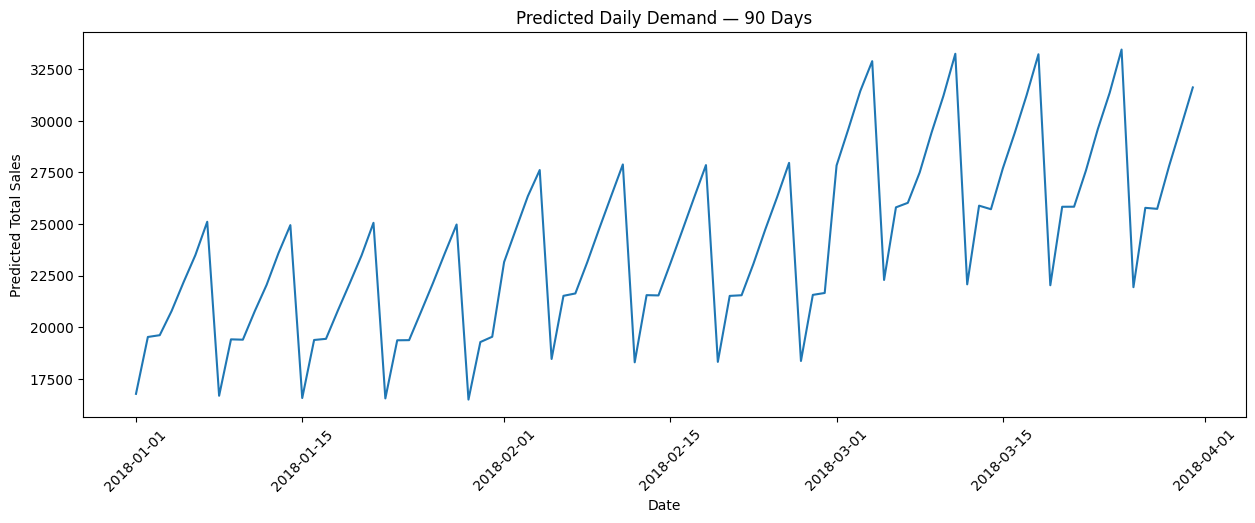

In [100]:
pred_plot = pred_df.copy()

pred_plot["date"] = pd.to_datetime(pred_plot["date"])

daily_pred = pred_plot.groupby("date")["sales"].sum()

plt.figure(figsize=(15, 5))

plt.plot(
    daily_pred.index,
    daily_pred.values
)

plt.xlabel("Date")
plt.ylabel("Predicted Total Sales")
plt.title("Predicted Daily Demand — 90 Days")

plt.xticks(rotation=45)

plt.show()

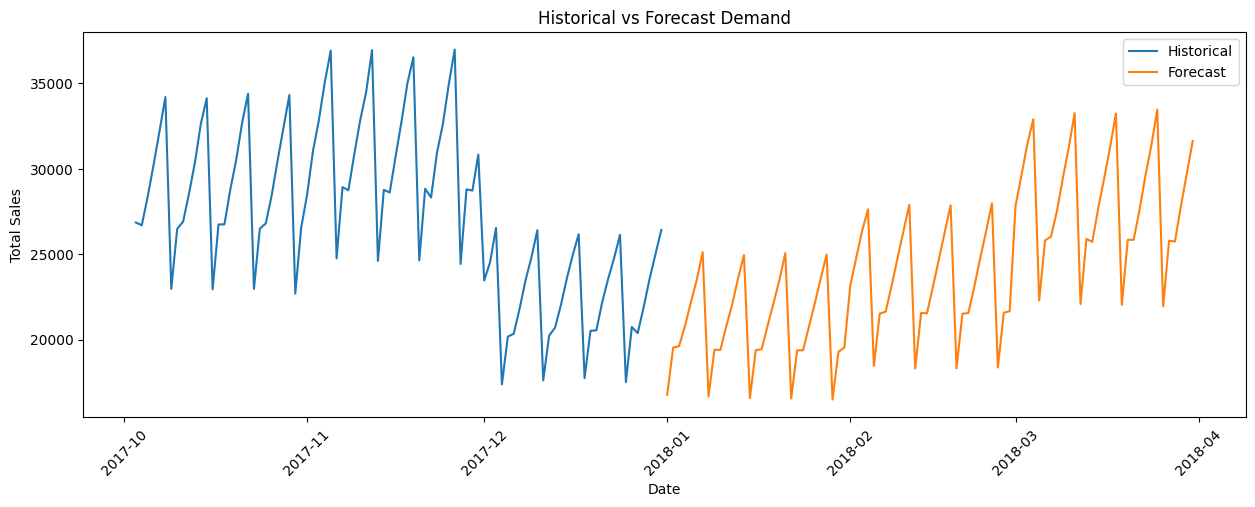

In [101]:
historical_daily = (
    train.groupby("date")["sales"]
    .sum()
    .tail(90)
)

plt.figure(figsize=(15, 5))

plt.plot(
    historical_daily.index,
    historical_daily.values,
    label="Historical"
)

plt.plot(
    daily_pred.index,
    daily_pred.values,
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Historical vs Forecast Demand")

plt.legend()
plt.xticks(rotation=45)

plt.show()

In [102]:
store_pred = (
    pred_df
    .groupby("store")["sales"]
    .mean()
    .sort_values(ascending=False)
)

print(store_pred)

store
2     61.928521
8     59.043055
3     55.065176
10    53.857764
9     50.766839
4     50.725200
1     43.697352
5     36.584646
6     36.577819
7     33.595222
Name: sales, dtype: float64


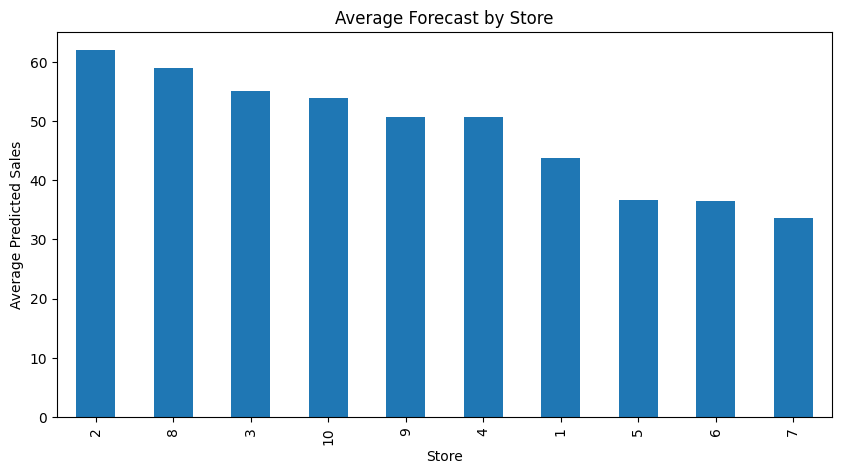

In [103]:
plt.figure(figsize=(10, 5))

store_pred.plot(kind="bar")

plt.xlabel("Store")
plt.ylabel("Average Predicted Sales")
plt.title("Average Forecast by Store")

plt.show()

In [104]:
item_pred = (
    pred_df
    .groupby("item")["sales"]
    .mean()
    .sort_values(ascending=False)
)

print(item_pred)

item
15    80.971373
28    80.827551
13    77.389340
18    77.160796
38    74.391181
45    74.296876
25    74.167776
22    73.642424
36    71.138795
8     70.752351
10    67.518787
11    65.318658
29    64.557833
12    64.259724
33    63.620015
24    61.036346
35    60.773218
50    60.214867
46    54.600192
14    54.472718
2     54.368248
7     54.304720
31    54.132976
6     53.797713
48    47.828316
43    47.724831
9     47.456235
20    44.143065
26    43.754130
32    40.776309
39    40.634222
21    37.194265
19    37.173006
30    36.734726
3     34.115758
42    33.683063
17    30.304763
40    27.147406
23    27.084891
37    26.937405
44    26.895640
49    26.734227
34    23.825819
16    23.235446
47    20.414944
27    20.325481
41    20.103848
1     20.058880
4     19.945459
5     17.261343
Name: sales, dtype: float64


In [106]:
print("Baseline RMSE :", rmse)
print("Old ML RMSE   :", ml_rmse)
print("Improved RMSE :", rmse2)

Baseline RMSE : 12.050653058255175
Old ML RMSE   : 7.8778078170427275
Improved RMSE : 7.618009575617826
